# Outlier Patch Detection on TR1 Data

Applies the per-patch amplitude perturbation analysis from `outlier_patch_test.ipynb`
to the first TR1 shear map (`SHE-1`).  The 48-patch tile mask serves as both the
patch decomposition and the jackknife regions.

In [ ]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

import heracles
import heracles.healpy
import heracles.dices as dices


## 1. Load catalog and build shear maps

We read `23405.fits` with `heracles.FitsCatalog` and select tomographic bin 1.
The shear (SHE) and weight (WHT) maps are produced by `heracles.map_catalogs`
using the LensMC ellipticity columns (`she_lensmc_e1/e2/weight`).

In [ ]:
from heracles.core import update_metadata

DATA_DIR          = "tr1_data"
DATA_PRODUCTS_DIR = "data_products"
CAT_FILE  = f"{DATA_DIR}/23405.fits"

nside     = 2048
lmax_data = 4000
lmax_mask = 6000
lmax_out  = 2500
lmin      = 500
nlbins    = 10
methods   = ["lensmc"]  # both shear estimators
bins      = [0] #list(range(7))          # 0 = full catalog, 1-6 = tomo bins

mask = hp.read_map("/home/jaimerzp/Documents/software/heracles/examples/tr1_data/tr1_mask.fits")
mask = hp.ud_grade(mask, nside_out=nside)

catalog  = heracles.FitsCatalog(CAT_FILE)
catalog.visibility = mask
catalogs = {0: catalog[f"tom_bin_id != -1"]}  # full catalog
# Switch off the tomographic binning for now, to increase the S/N of the maps and avoid outliers in the low-z bins
#for i in range(1, 7):
#    catalogs[i] = catalog[f"tom_bin_id == {i}"]

mapper_data = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_data)
mapper_mask = heracles.healpy.HealpixMapper(nside=nside, lmax=lmax_mask)

# Create data-products directory tree
os.makedirs(DATA_PRODUCTS_DIR, exist_ok=True)
for method in methods:
    os.makedirs(f"{DATA_PRODUCTS_DIR}/{method}", exist_ok=True)

she_maps_all = {}
wht_maps_all = {}

for method in methods:
    cache_file = f"{DATA_PRODUCTS_DIR}/{method}/maps_nside_{nside}.fits"

    if os.path.exists(cache_file):
        maps = heracles.read_maps(cache_file)
        she_maps_all[method] = {k: maps[k] for k in maps if k[0] == "SHE"}
        wht_maps_all[method] = {k: maps[k] for k in maps if k[0] == "WHT"}
        print(f"  Loaded maps [{method}] from cache")
    else:
        fields_she = {
            "SHE": heracles.Shears(
                mapper_data,
                "right_ascension",
                "declination",
                f"she_{method}_e1",
                f"-she_{method}_e2",
                f"she_{method}_weight",
                mask="WHT",
            ),
        }
        fields_wht = {
            "WHT": heracles.Weights(
                mapper_mask,
                "right_ascension",
                "declination",
                f"she_{method}_weight",
            ),
        }
        she_maps_all[method] = heracles.map_catalogs(fields_she, catalogs)
        wht_maps_all[method] = heracles.map_catalogs(fields_wht, catalogs)
        heracles.write_maps(cache_file, {**she_maps_all[method], **wht_maps_all[method]}, clobber=True)
        print(f"  Mapped and cached [{method}]  ({len(bins)} bins)")

print(f"Data-products dir: {DATA_PRODUCTS_DIR}/")


## 2. Build the patch segmentation map

We divide the survey footprint into roughly 20-sq-deg patches using
`skysegmentor.segmentmapN` on the WHT weight map.

In [ ]:
import skysegmentor

# Per-method, per-bin bias from metadata
b_all = {
    method: {
        ibin: she_maps_all[method][("SHE", ibin)].dtype.metadata["bias"]
        for ibin in bins
    }
    for method in methods
}

# Patch layout is method- and bin-independent
fsky      = mask.sum() / hp.nside2npix(nside)
area_deg2 = fsky * 4 * np.pi * (180 / np.pi) ** 2
n_patches = max(1, round(area_deg2 / 20))
print(f"Survey area: {area_deg2:.1f} sq deg  \u2192  {n_patches} patches of ~{area_deg2/n_patches:.1f} sq deg each")

jkmap = skysegmentor.segmentmapN(mask, n_patches)
print(f"jkmap unique labels: {np.unique(jkmap[jkmap > 0]).astype(int)}")


In [ ]:
# ── Diagnostic: SHE-1 maps for both methods + patch regions ──
footprint_pix = np.where(she_maps_all["lensmc"][("SHE", 0)][0] != 0)[0]
vec = np.array(hp.pix2vec(nside, footprint_pix))
centre_vec = vec.mean(axis=1)
centre_vec /= np.linalg.norm(centre_vec)
lon_c, lat_c = hp.vec2ang(centre_vec, lonlat=True)
lon_c, lat_c = float(lon_c), float(lat_c)

fig = plt.figure(figsize=(18, 8))

for row, method in enumerate(methods):
    she_m = she_maps_all[method]
    hp.mollview(
        she_m[("SHE", 0)][0], fig=fig, sub=(2, 3, row * 3 + 1),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  Q shear", unit="Q",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        she_m[("SHE", 0)][1], fig=fig, sub=(2, 3, row * 3 + 2),
        rot=(lon_c, lat_c, 0),
        title=f"{method}  U shear", unit="U",
        cmap="RdBu_r", notext=True,
    )
    hp.mollview(
        jkmap, fig=fig, sub=(2, 3, row * 3 + 3),
        rot=(lon_c, lat_c, 0),
        title="Patch mask", unit="patch ID",
        cmap="tab20", notext=True,
    )

hp.graticule(dpar=5, dmer=5, alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Heracles setup

In [ ]:
# Per-patch and full-footprint naturalspice: SHE @ lmax_data, WHT @ lmax_mask
fields = {
    "SHE": heracles.Shears(mapper_data, mask="WHT"),
    "WHT": heracles.Weights(mapper_data),
}
print(f"Data mapper: nside={mapper_data.nside}, lmax={mapper_data.lmax}")
print(f"Mask mapper: nside={mapper_mask.nside}, lmax={mapper_mask.lmax}")

## 4. Per-patch alms and pseudo-$C_\ell$

For each patch we:
1. Mask the shear and weight maps to that patch's pixels
2. Transform to alms
3. Compute the pseudo-$C_\ell$

In [25]:
import heracles.dices as dices

# Nested dicts: [method][label][ibin]
# patch_data_alms and patch_mask_alms are cached to disk and reused in section 9
all_data_cls    = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
all_mask_cls    = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
patch_data_alms = {method: {ibin: {} for ibin in bins} for method in methods}
patch_mask_alms = {method: {ibin: {} for ibin in bins} for method in methods}

for method in methods:
    for label in range(1, n_patches + 1):
        cls_cache  = f"{DATA_PRODUCTS_DIR}/{method}/pseudo_cls_patch_{label:03d}_lmax{lmax_data}.fits"
        alms_cache = f"{DATA_PRODUCTS_DIR}/{method}/alms_patch_{label:03d}_lmax{lmax_data}.fits"
        patch_pix  = jkmap == label

        if os.path.exists(alms_cache):
            # heracles.read_alms restores dtype metadata (including spin) from FITS
            alms_data = heracles.read_alms(alms_cache)
            for ibin in bins:
                patch_data_alms[method][ibin][label] = alms_data[("SHE", ibin)]
                patch_mask_alms[method][ibin][label] = alms_data[("WHT", ibin)]
        else:
            # Compute per-patch alms and cache them
            alms_out = {}
            for ibin in bins:
                she = she_maps_all[method][("SHE", ibin)]
                wht = wht_maps_all[method][("WHT", ibin)]
                b   = b_all[method][ibin]

                she_p = she.copy(); she_p[:, ~patch_pix] = 0.0
                wht_p = wht.copy(); wht_p[~patch_pix]    = 0.0
                update_metadata(she_p, fsky=fsky/n_patches, bias=b/n_patches)

                patch_data_alms[method][ibin][label] = mapper_data.transform(she_p)
                patch_mask_alms[method][ibin][label] = mapper_mask.transform(wht_p)
                alms_out[("SHE", ibin)] = patch_data_alms[method][ibin][label]
                alms_out[("WHT", ibin)] = patch_mask_alms[method][ibin][label]
            heracles.write_alms(alms_cache, alms_out, clobber=True)

        if os.path.exists(cls_cache):
            # Load pseudo-Cls from cache
            combined = heracles.read(cls_cache)
            for ibin in bins:
                all_data_cls[method][label][ibin] = {("SHE", "SHE", ibin, ibin): combined[("SHE", "SHE", ibin, ibin)]}
                all_mask_cls[method][label][ibin] = {("WHT", "WHT", ibin, ibin): combined[("WHT", "WHT", ibin, ibin)]}
        else:
            # Compute pseudo-Cls from alms and cache them
            combined = {}
            for ibin in bins:
                all_data_cls[method][label][ibin] = heracles.angular_power_spectra(
                    {("SHE", ibin): patch_data_alms[method][ibin][label]})
                all_mask_cls[method][label][ibin] = heracles.angular_power_spectra(
                    {("WHT", ibin): patch_mask_alms[method][ibin][label]})
                combined.update(all_data_cls[method][label][ibin])
                combined.update(all_mask_cls[method][label][ibin])
            heracles.write(cls_cache, combined, clobber=True)

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print("done.")


  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 5. Unmix the Cls of each region

`naturalspice` divides the data correlation function by the mask correlation
function in real space, correcting for mode-mixing without an explicit
mixing-matrix inversion.

In [26]:
ell_data = np.arange(0, lmax_data + 1)
ell_out  = np.arange(0, lmax_out + 1)
ledges = np.logspace(np.log10(lmin), np.log10(lmax_out), nlbins + 1)
lgrid = 0.5 * (ledges[:-1] + ledges[1:])

In [27]:
from heracles.unmixing import _naturalspice, logistic
try:
    from copy import replace
except ImportError:
    from dataclasses import replace

rcond     = 0.7
k         = 130.0
rcond_str = f"rcond{rcond:.0e}".replace("e-0", "e-").replace("e+0", "e+")

all_corrf          = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}
all_unmixed_binned = {method: {label: {} for label in range(1, n_patches + 1)} for method in methods}

print(f"Two-step naturalspice  (rcond={rcond}, k={k}) ...")
for method in methods:
    for label in range(1, n_patches + 1):
        corrf_file = f"{DATA_PRODUCTS_DIR}/{method}/corrf_patch_lmax_{lmax_out}_{label:03d}_rcond_{rcond_str}_k_{k:.1f}.fits"
        cls_file   = f"{DATA_PRODUCTS_DIR}/{method}/decoupled_cls_patch_lmax_{lmax_out}_{label:03d}_rcond_{rcond_str}_k_{k:.1f}.fits"

        if os.path.exists(corrf_file) and os.path.exists(cls_file):
            corrf_data = heracles.read(corrf_file)
            cls_data   = heracles.read(cls_file)
            for ibin in bins:
                key = ("SHE", "SHE", ibin, ibin)
                all_corrf[method][label][ibin]          = corrf_data[key]
                all_unmixed_binned[method][label][ibin] = cls_data[key]
        else:
            corrf_out, cls_out = {}, {}
            for ibin in bins:
                data = all_data_cls[method][label][ibin]
                mask = all_mask_cls[method][label][ibin]
                key  = ("SHE", "SHE", ibin, ibin)

                wd = heracles.cl2corr(heracles.binned(data, np.arange(0, lmax_mask + 2)))
                wm = heracles.cl2corr(mask)
                for m_key in list(wm.keys()):
                    a = wm[m_key].array
                    wm[m_key] = replace(wm[m_key], array=a * logistic(np.log10(abs(a)), x0=np.log10(rcond * a.max()), k=k))

                corrf     = _naturalspice(wd, wm, fields)
                unmixed   = heracles.binned(heracles.corr2cl(corrf), np.arange(0, lmax_out + 1))
                binned_cl = heracles.binned(unmixed, ledges)

                all_corrf[method][label][ibin]          = corrf[key]
                all_unmixed_binned[method][label][ibin] = binned_cl[key]
                corrf_out[key] = corrf[key]
                cls_out[key]   = binned_cl[key]

            heracles.write(corrf_file, corrf_out, clobber=True)
            heracles.write(cls_file,   cls_out,   clobber=True)

        if label % 5 == 0 or label == n_patches:
            print(f"  [{method}] patch {label}/{n_patches}", end=", ", flush=True)
    print("done.")


Two-step naturalspice  (rcond=0.7, k=130.0) ...
  [lensmc] patch 5/25,   [lensmc] patch 10/25,   [lensmc] patch 15/25,   [lensmc] patch 20/25,   [lensmc] patch 25/25, done.


## 6. Full-footprint $C_\ell$

The full-footprint alm is the sum of per-patch alms (SHT linearity — no extra SHTs).
The covariance is the **sample covariance** of the per-region unmixed Cls,
characterising region-to-region scatter.

In [28]:
from heracles.transforms import _cached_gauss_legendre

rcond_full     = 0.1
k_full         = 100.0
rcond_str_full = f"rcond{rcond_full:.0e}".replace("e-0", "e-").replace("e+0", "e+")

all_cl_full    = {method: {} for method in methods}
all_corrf_full = {method: {} for method in methods}

for method in methods:
    corrf_cache = f"{DATA_PRODUCTS_DIR}/full_footprint_corrf_{method}_lmax_{lmax_out}_rcond_{rcond_str_full}_k_{k_full:.1f}.fits"
    cls_cache   = f"{DATA_PRODUCTS_DIR}/full_footprint_cls_{method}_lmax_{lmax_out}_rcond_{rcond_str_full}_k_{k_full:.1f}.fits"

    if os.path.exists(corrf_cache) and os.path.exists(cls_cache):
        print(f"Loading full-footprint [{method}] from cache...")
        corrf_data = heracles.read(corrf_cache)
        cls_data   = heracles.read(cls_cache)
        for ibin in bins:
            key    = ("SHE", "SHE", ibin, ibin)
            cl_obj = cls_data[key]
            all_corrf_full[method][ibin] = corrf_data[key]
            all_cl_full[method][ibin]    = cl_obj
    else:
        print(f"Full-footprint two-step naturalspice [{method}]...")
        corrf_out, cls_out = {}, {}
        for ibin in bins:
            she_full = she_maps_all[method][("SHE", ibin)]
            wht_full = wht_maps_all[method][("WHT", ibin)]
            alm_full_shear = mapper_data.transform(she_full)
            alm_full_mask  = mapper_mask.transform(wht_full)
            full_data_cls = heracles.angular_power_spectra({("SHE", ibin): alm_full_shear})
            full_mask_cls = heracles.angular_power_spectra({("WHT", ibin): alm_full_mask})
            key = ("SHE", "SHE", ibin, ibin)

            wd = heracles.cl2corr(heracles.binned(full_data_cls, np.arange(0, lmax_mask + 2)))
            wm = heracles.cl2corr(full_mask_cls)
            for m_key in list(wm.keys()):
                a = wm[m_key].array
                wm[m_key] = replace(wm[m_key], array=a * logistic(np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))

            full_corrf     = _naturalspice(wd, wm, fields)
            full_unmixed   = heracles.binned(heracles.corr2cl(full_corrf), np.arange(0, lmax_out + 1))
            full_unmixed_b = heracles.binned(full_unmixed, ledges)
            all_corrf_full[method][ibin] = full_corrf[key]
            all_cl_full[method][ibin]    = full_unmixed_b[key]
            corrf_out[key] = full_corrf[key]
            cls_out[key]   = full_unmixed_b[key]

        heracles.write(corrf_cache, corrf_out, clobber=True)
        heracles.write(cls_cache,   cls_out,   clobber=True)
        print(f"  {method}: done.")

# theta axis shared by all corrfs (Gauss-Legendre quadrature points of cl2corr)
xvals, _ = _cached_gauss_legendre(lmax_mask + 1)
theta_full = np.degrees(np.arccos(xvals))


Loading full-footprint [lensmc] from cache...


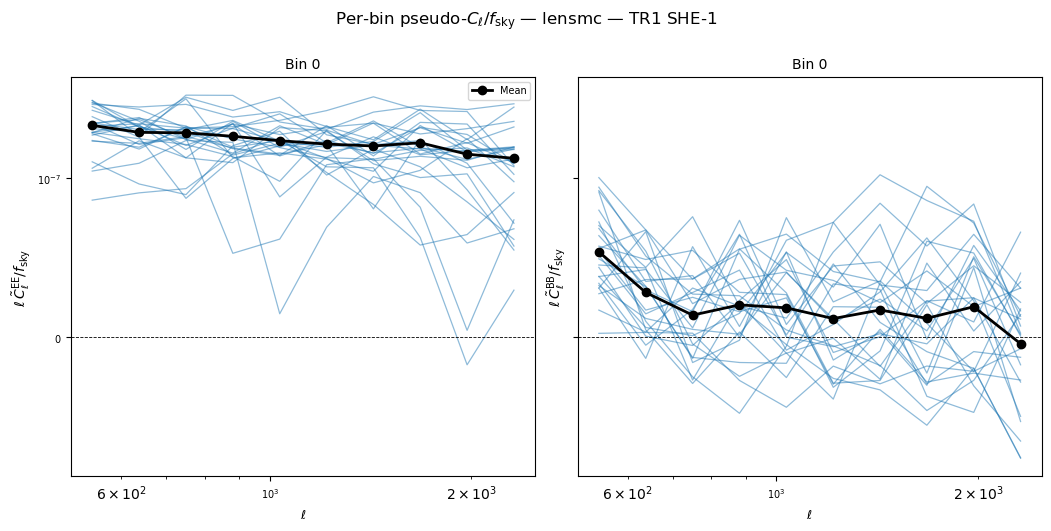

In [29]:
for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        key        = ("SHE", "SHE", ibin, ibin)
        patch_fsky = fsky / n_patches

        # bin each patch's pseudo-Cl with ledges and rescale by fsky
        binned_ee = np.array([
            np.array(heracles.binned(all_data_cls[method][label][ibin], ledges)[key][0, 0])
            for label in range(1, n_patches + 1)
        ])
        binned_bb = np.array([
            np.array(heracles.binned(all_data_cls[method][label][ibin], ledges)[key][1, 1])
            for label in range(1, n_patches + 1)
        ])
        ell = heracles.binned(all_data_cls[method][1][ibin], ledges)[key].ell

        for row, (label_str, patch_arr) in enumerate([("EE", binned_ee), ("BB", binned_bb)]):
            ax = axes[row]
            for k in range(n_patches):
                ax.plot(ell, ell * patch_arr[k] / patch_fsky,
                        color='C0', alpha=0.5, lw=0.9, zorder=2)
            ax.plot(ell, ell * patch_arr.mean(axis=0) / patch_fsky, 'o-',
                    color="k", lw=2, zorder=5, label="Mean")
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-7)
            ax.set_xlabel(r"$\ell$", fontsize=9)
            if col == 0:
                ax.set_ylabel(r"$\ell\,\tilde{C}_\ell^{\rm " + label_str + r"} / f_{\rm sky}$", fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        r"Per-bin pseudo-$C_\ell / f_{\rm sky}$" + f" \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


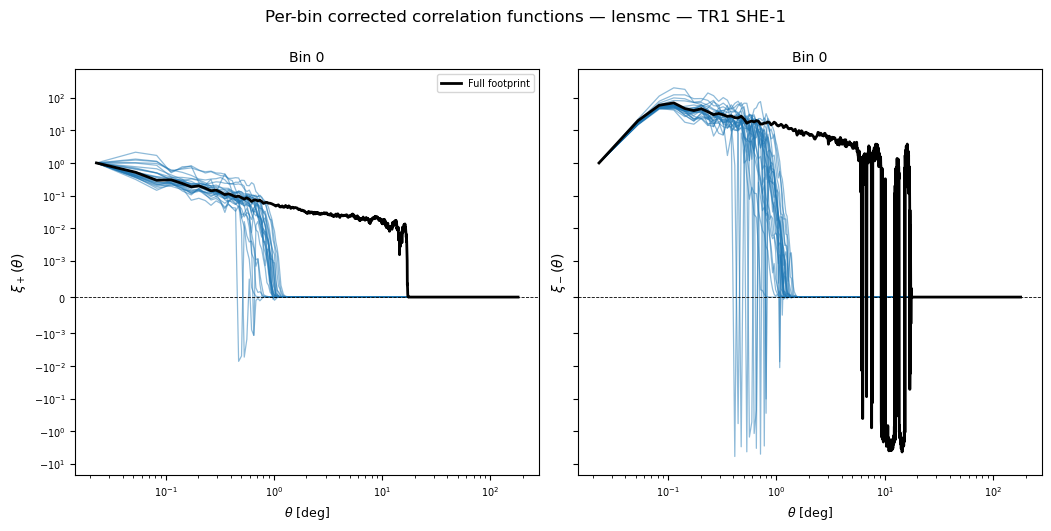

In [30]:
_sort      = np.argsort(theta_full)
theta_plot = theta_full[_sort]

for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        full_xip  = np.array(all_corrf_full[method][ibin][0, 0])[_sort]
        full_xim  = np.array(all_corrf_full[method][ibin][1, 1])[_sort]
        patch_xip = np.array([np.array(all_corrf[method][label][ibin][0, 0])[_sort] for label in range(1, n_patches + 1)])
        patch_xim = np.array([np.array(all_corrf[method][label][ibin][1, 1])[_sort] for label in range(1, n_patches + 1)])

        for row, (label_str, full_arr, patch_arr) in enumerate([
            (r"$\xi_+(\theta)$", full_xip, patch_xip),
            (r"$\xi_-(\theta)$", full_xim, patch_xim),
        ]):
            ax = axes[row]
            for k in range(n_patches):
                ax.plot(theta_plot, patch_arr[k]/patch_arr[k][0], color='C0', alpha=0.5, lw=0.9, zorder=2)
            ax.plot(theta_plot, full_arr/full_arr[0], color="k", lw=2, zorder=5, label="Full footprint")
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-3)
            ax.set_xlabel(r"$\theta$ [deg]", fontsize=9)
            if col == 0:
                ax.set_ylabel(label_str, fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        f"Per-bin corrected correlation functions \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


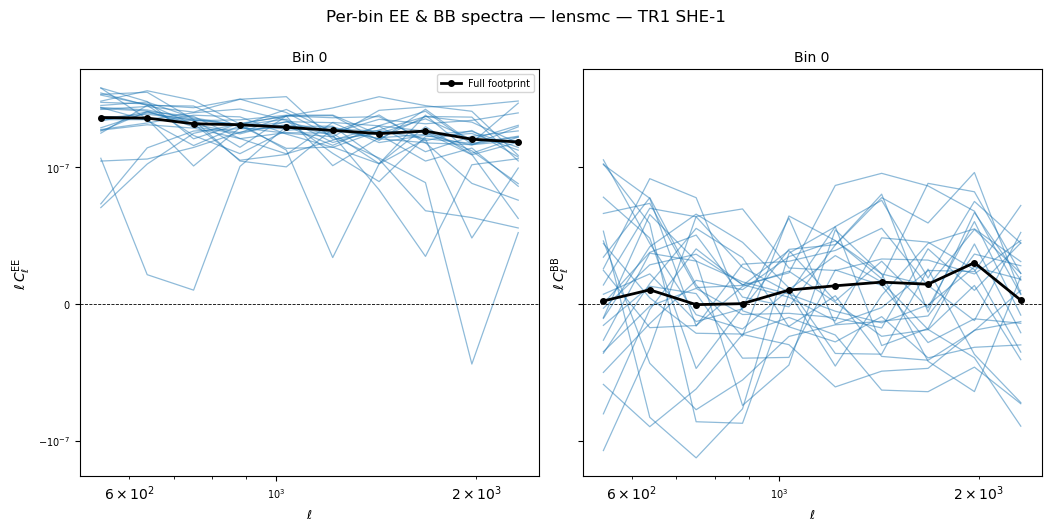

In [31]:
patch_colors = plt.cm.tab20(np.linspace(0, 1, n_patches))

for method in methods:
    nrows = len(bins)
    fig, axes = plt.subplots(nrows, 2, figsize=(2 * 5.2, nrows * 5.2), sharey="row",
                             constrained_layout=True)

    for col, ibin in enumerate(bins):
        cl_data = all_cl_full[method][ibin]

        for row, (component, comp_idx) in enumerate([
            ("EE", (0, 0)),
            ("BB", (1, 1)),
        ]):
            ax = axes[row]

            # Per-region deconvolved Cls
            patches = np.array([np.array(all_unmixed_binned[method][label][ibin][comp_idx]) for label in range(1, n_patches + 1)])
            for k in range(patches.shape[0]):
                ax.plot(lgrid, lgrid * patches[k],
                        color='C0', alpha=0.5, lw=0.9, zorder=2)

            # Full-footprint Cl
            ax.plot(lgrid, lgrid * np.array(cl_data[comp_idx]),
                    "o-", ms=4, lw=2, color="k", zorder=5, label="Full footprint")

            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-7)
            ax.set_xlabel(r"$\ell$", fontsize=9)
            if col == 0:
                ax.set_ylabel(r"$\ell\,C_\ell^{\rm " + component + r"}$", fontsize=10)
            ax.set_title(f"Bin {ibin}", fontsize=10)
            ax.tick_params(labelsize=7)
            if col == nrows - 1 and row == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(
        f"Per-bin EE & BB spectra \u2014 {method} \u2014 TR1 SHE-1\n",
        fontsize=12,
    )
    plt.show()


## 7. Leave-one-out $\chi^2$ outlier test

For each patch $k$ we compare its decoupled $C_\ell^{EE}$ to the mean of all
**other** patches:
$$\mu_{{-k}} = \frac{{1}}{{N-1}}\sum_{{j\neq k}} C_\ell^{{EE,j}}$$

The leave-one-out (LOO) $\chi^2$ is the Mahalanobis distance using the
covariance estimated from those same $N-1$ patches, so the outlier cannot
inflate its own reference or covariance.  Bins with $\ell < \ell_{{\min}}$
are excluded.

In [32]:
from scipy.stats import chi2 as chi2_dist

print(f"Using {nlbins} ell bins with ell >= {lmin}\n")

# all_chi2_loo[method][ibin], shape (N,)
all_chi2_loo = {method: {} for method in methods}

for method in methods:
    for ibin in bins:
        cls_chi2 = np.array([np.array(all_unmixed_binned[method][label][ibin][0, 0]) for label in range(1, n_patches + 1)])

        chi2_loo = np.zeros(n_patches)
        for k in range(n_patches):
            idx_rest    = [j for j in range(n_patches) if j != k]
            mu_loo      = cls_chi2[idx_rest].mean(axis=0)
            cov_loo     = np.cov(cls_chi2[idx_rest].T)
            diff        = cls_chi2[k] - mu_loo
            chi2_loo[k] = diff @ np.linalg.inv(cov_loo) @ diff

        all_chi2_loo[method][ibin] = chi2_loo
        n_out = (chi2_loo / nlbins > 3).sum()
        print(f"  [{method}] bin {ibin}: {n_out}/{n_patches} outliers  "
              f"(max reduced chi2 = {chi2_loo.max()/nlbins:.2f})")
    print()


Using 10 ell bins with ell >= 500

  [lensmc] bin 0: 5/25 outliers  (max reduced chi2 = 5.91)



## 8. B-mode null test

We test the null hypothesis $H_0: C_\ell^{BB} = 0$ at two levels:

1. **Full footprint** — is the full-survey BB spectrum consistent with zero?  
   We use the sample covariance of the per-patch BBs divided by $N$ as the
   covariance of the full-footprint estimator, then form
   $\chi^2 = \mathbf{C}_\ell^{BB\,T}\,\mathrm{Cov}^{-1}\,\mathbf{C}_\ell^{BB}$
   and compare to $\chi^2(p)$.

2. **Per patch** — which individual patches show significant non-zero BB?  
   For each patch $k$ we use the leave-one-out covariance of the BB spectra
   from the remaining $N-1$ patches as the noise model and test
   $\mathbf{C}_\ell^{BB,k}$ against zero.

In [33]:
print(f"B-mode null test  (H\u2080: C\u2113\u1d2e\u1d2e = 0,  {nlbins} dof)\n")

# all_chi2_bb_full[method][ibin]  = {"chi2": scalar}
# all_chi2_bb_patch[method][ibin] = array shape (N,)
all_chi2_bb_full  = {method: {} for method in methods}
all_chi2_bb_patch = {method: {} for method in methods}

for method in methods:
    for ibin in bins:
        cls_patches_bb = np.array([np.array(all_unmixed_binned[method][label][ibin][1, 1]) for label in range(1, n_patches + 1)])

        # Full-footprint test
        cov_bb_full  = np.cov(cls_patches_bb.T) / n_patches
        cl_bb_full   = np.array(all_cl_full[method][ibin][1, 1])
        chi2_bb_full = cl_bb_full @ np.linalg.inv(cov_bb_full) @ cl_bb_full
        all_chi2_bb_full[method][ibin] = {"chi2": chi2_bb_full}

        # Per-patch: test against zero using LOO cov from BB scatter
        chi2_bb_patch = np.zeros(n_patches)
        for k in range(n_patches):
            idx_rest         = [j for j in range(n_patches) if j != k]
            cov_loo_bb       = np.cov(cls_patches_bb[idx_rest].T)
            chi2_bb_patch[k] = cls_patches_bb[k] @ np.linalg.inv(cov_loo_bb) @ cls_patches_bb[k]
        all_chi2_bb_patch[method][ibin] = chi2_bb_patch

        n_out = (chi2_bb_patch / nlbins > 3).sum()
        print(f"  [{method}] bin {ibin}:  full \u03c7\u00b2/nlbins = {chi2_bb_full/nlbins:.3f}  |  "
              f"per-patch outliers = {n_out}/{n_patches}")
    print()


B-mode null test  (H₀: Cℓᴮᴮ = 0,  10 dof)

  [lensmc] bin 0:  full χ²/nlbins = 2.499  |  per-patch outliers = 4/25



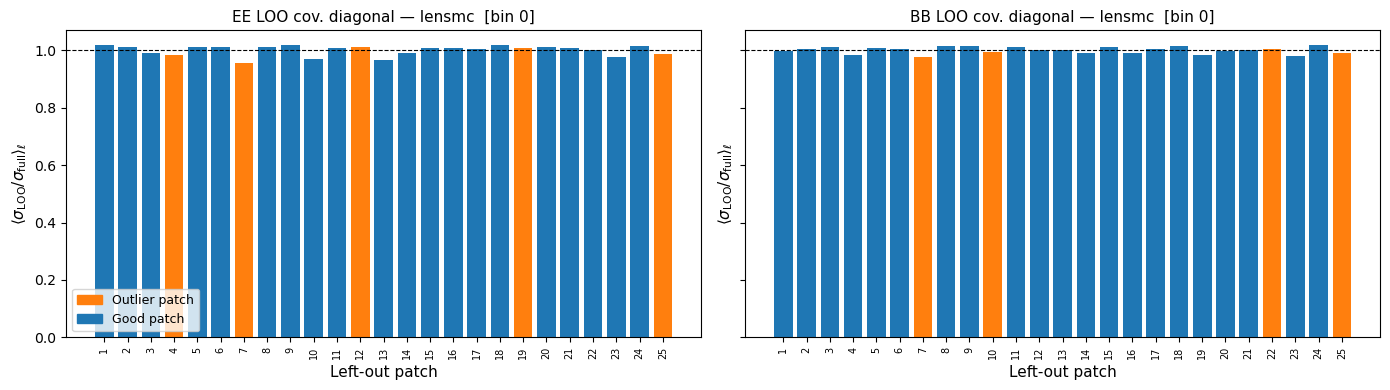

In [34]:
# LOO covariance diagonal diagnostic
# For each left-out patch k, compute the ell-averaged ratio of diag(Cov_{-k}) to diag(Cov_full).
# A ratio far from 1 signals that the covariance is driven by that single region.

for method in methods:
    for ibin in bins:
        cls_ee = np.array([np.array(all_unmixed_binned[method][label][ibin][0, 0]) for label in range(1, n_patches + 1)])
        cls_bb = np.array([np.array(all_unmixed_binned[method][label][ibin][1, 1]) for label in range(1, n_patches + 1)])

        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
        patch_labels = [str(k + 1) for k in range(n_patches)]

        for ax, (label_str, cls, chi2_data) in zip(axes, [
            ("EE", cls_ee, all_chi2_loo[method][ibin]),
            ("BB", cls_bb, all_chi2_bb_patch[method][ibin]),
        ]):
            diag_full = np.sqrt(np.diag(np.cov(cls.T)))

            ratios = np.array([
                np.mean(np.sqrt(np.diag(np.cov(cls[[j for j in range(n_patches) if j != k]].T))) / diag_full)
                for k in range(n_patches)
            ])
            is_out = chi2_data / nlbins > 3
            colors = ["C1" if o else "C0" for o in is_out]

            ax.bar(patch_labels, ratios, color=colors)
            ax.axhline(1, color="k", lw=0.8, ls="--")
            ax.set_xlabel("Left-out patch", fontsize=11)
            ax.set_ylabel(r"$\langle\sigma_{\rm LOO} / \sigma_{\rm full}\rangle_\ell$", fontsize=11)
            ax.set_title(f"{label_str} LOO cov. diagonal \u2014 {method}  [bin {ibin}]", fontsize=11)
            ax.tick_params(axis="x", labelsize=7, rotation=90)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color="C1", label="Outlier patch"),
            plt.Rectangle((0, 0), 1, 1, color="C0", label="Good patch"),
        ]
        axes[0].legend(handles=handles, fontsize=9)
        plt.tight_layout()
        plt.show()


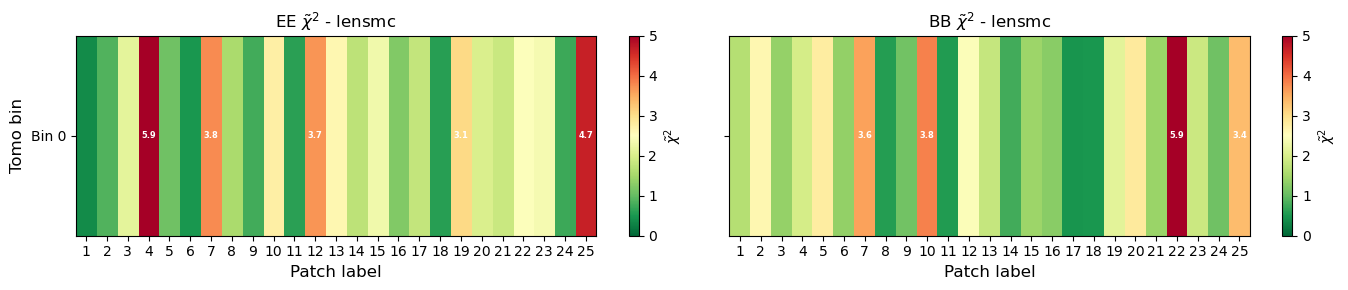

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

for row, method in enumerate(methods):
    for col, (label_str, chi2_data) in enumerate([
        ("EE", all_chi2_loo),
        ("BB", all_chi2_bb_patch),
    ]):
        ax = axes[col]
        mat = np.array([chi2_data[method][ibin] / nlbins for ibin in bins])
        im  = ax.imshow(mat, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=5,
                        extent=[0.5, n_patches + 0.5, len(bins) - 0.5, -0.5])
        ax.set_xlabel("Patch label", fontsize=12)
        if col == 0:
            ax.set_ylabel("Tomo bin", fontsize=12)
        ax.set_xticks(range(1, n_patches + 1))
        ax.set_yticks(range(len(bins)))
        ax.set_yticklabels([f"Bin {i}" for i in bins])
        ax.set_title(rf"{label_str} $\tilde{{\chi}}^2$ - {method}", fontsize=12)
        plt.colorbar(im, ax=ax, label=r"$\tilde{\chi}^2$")
        for bi, ibin in enumerate(bins):
            for k in range(n_patches):
                val = chi2_data[method][ibin][k] / nlbins
                if val > 3:
                    ax.text(k + 1, bi, f"{val:.1f}", ha="center", va="center",
                            fontsize=6, color="white", fontweight="bold")

plt.tight_layout()
plt.show()


/tmp/ipykernel_14580/90271142.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


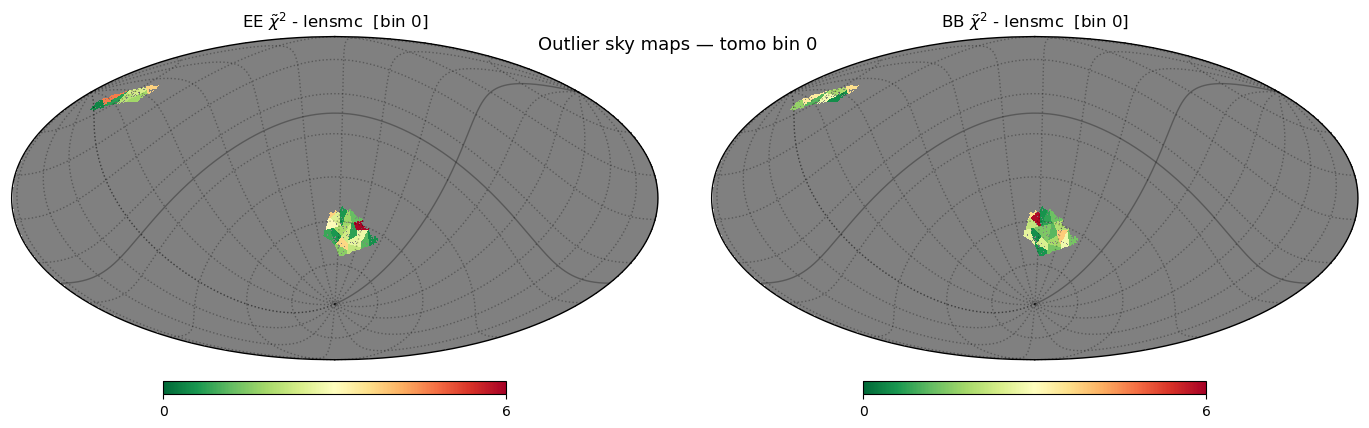

In [36]:
for ibin in bins:
    fig = plt.figure(figsize=(14, 8))
    for row, method in enumerate(methods):
        for col, (label_str, chi2_data) in enumerate([
            ("EE", all_chi2_loo),
            ("BB", all_chi2_bb_patch),
        ]):
            sky_chi2 = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=np.float64)
            for k in range(n_patches):
                sky_chi2[jkmap == k + 1] = chi2_data[method][ibin][k] / nlbins
            hp.mollview(
                sky_chi2, fig=fig, sub=(2, 2, row * 2 + col + 1),
                rot=(lon_c, lat_c, 0),
                title=rf"{label_str} $\tilde{{\chi}}^2$ - {method}  [bin {ibin}]",
                cmap="RdYlGn_r", min=0, max=6, notext=True,
            )
    hp.graticule(dpar=5, dmer=5, alpha=0.3)
    plt.suptitle(f"Outlier sky maps \u2014 tomo bin {ibin}", fontsize=13)
    plt.tight_layout()
    plt.show()


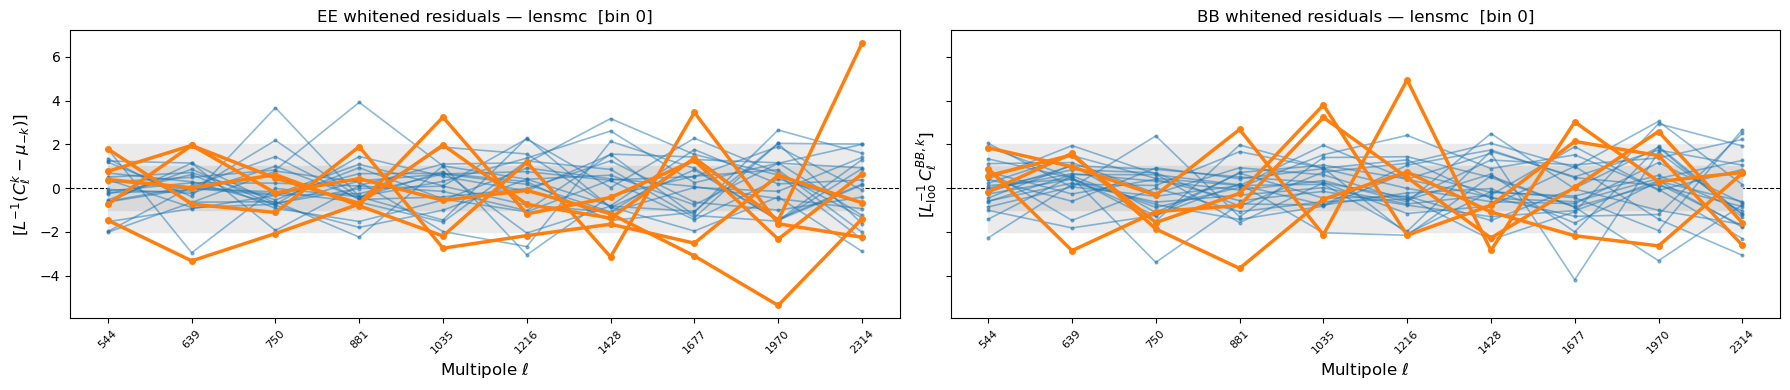

In [37]:
for ibin in bins:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey="row")

    for row, method in enumerate(methods):
        for col, (label_str, comp_idx, chi2_data, null) in enumerate([
            ("EE", (0, 0), all_chi2_loo,      False),
            ("BB", (1, 1), all_chi2_bb_patch, True),
        ]):
            ax = axes[col]
            cls       = np.array([np.array(all_unmixed_binned[method][label][ibin][comp_idx]) for label in range(1, n_patches + 1)])
            chi2_vals = chi2_data[method][ibin]

            ax.axhline(0, color="k", lw=0.8, ls="--", zorder=0)
            ax.fill_between(range(nlbins), -1, 1, color="0.85", zorder=1, label=r"$1\sigma$")
            ax.fill_between(range(nlbins), -2, 2, color="0.92", zorder=0, label=r"$2\sigma$")

            for k in range(n_patches):
                idx_rest = [j for j in range(n_patches) if j != k]
                cov_loo  = np.cov(cls[idx_rest].T)
                L        = np.linalg.cholesky(cov_loo)
                mu       = np.zeros(nlbins) if null else cls[idx_rest].mean(axis=0)
                w        = np.linalg.solve(L, cls[k] - mu)

                is_out = chi2_vals[k] / nlbins > 3
                lbl    = f"Patch {k+1} (outlier)" if is_out else ("Good patches" if k == 0 else None)
                ax.plot(range(nlbins), w, color="C1" if is_out else "C0",
                        lw=2.5 if is_out else 1.2, alpha=1.0 if is_out else 0.5,
                        marker="o", ms=4 if is_out else 2,
                        zorder=5 if is_out else 2, label=lbl)

            ax.set_xticks(range(nlbins))
            ax.set_xticklabels([f"{l:.0f}" for l in lgrid], rotation=45, fontsize=8)
            ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
            ax.set_ylabel(r"$[L^{-1}(C_\ell^k - \mu_{-k})]$" if not null
                          else r"$[L^{-1}_{\rm loo}\,C_\ell^{BB,k}]$", fontsize=12)
            ax.set_title(f"{label_str} whitened residuals \u2014 {method}  [bin {ibin}]", fontsize=12)
            #ax.set_yscale("symlog", linthresh=5E0)
            #ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 9. BB Detection Significance via Jackknife Covariance

We estimate the covariance of the full-footprint $C_\ell^{BB}$ using the **delete-1 jackknife**:

1. Compute per-patch shear and weight alms.
2. For each region $k$: sum all alms **except** $k$ to form the leave-one-out (LOO) full-footprint alms.
3. Apply naturalspice unmixing to each LOO pseudo-$C_\ell$.
4. Feed the ensemble of $N$ LOO spectra into .
5. Compute $\chi^2 = \mathbf{C}^{BB\,T}\,\mathrm{Cov}^{-1}\,\mathbf{C}^{BB}$ for:
   - the **full footprint**, and
   - a **clean** version that excludes the bad patches identified in the per-patch B-mode null test.


In [43]:
# Jackknife covariance for BB detection significance.
#
# Step 1: compute (or load from cache) all LOO Cls — one FITS file per
#         method/removed-patch, containing all tomographic bins.
# Step 2: jackknife covariance + chi2 for full footprint and clean footprint.
#         The clean ensemble reuses the already-computed LOO Cls restricted
#         to good patches (no redundant naturalspice calls).

spin_she = fields["SHE"].spin  # 2
spin_wht = fields["WHT"].spin  # 0

all_jk_chi2_bb = {method: {} for method in methods}

# all_loo_cls[method][ibin][k_p] = {key: Result}
all_loo_cls = {method: {ibin: {} for ibin in bins} for method in methods}

for method in methods:
    for k_p in range(1, n_patches + 1):
        loo_cache = (f"{DATA_PRODUCTS_DIR}/{method}/"
                     f"loo_cls_remove_{k_p:03d}_lmax{lmax_out}"
                     f"_rcond_{rcond_str_full}_k_{k_full:.1f}.fits")

        if os.path.exists(loo_cache):
            saved = heracles.read(loo_cache)
            for ibin in bins:
                key = ("SHE", "SHE", ibin, ibin)
                all_loo_cls[method][ibin][k_p] = {key: saved[key]}
        else:
            rest    = [j for j in range(1, n_patches + 1) if j != k_p]
            to_save = {}
            for ibin in bins:
                key   = ("SHE", "SHE", ibin, ibin)
                alm_d = sum(patch_data_alms[method][ibin][j] for j in rest)
                alm_m = sum(patch_mask_alms[method][ibin][j] for j in rest)
                b_loo = b_all[method][ibin] * (n_patches - 1) / n_patches
                update_metadata(alm_d, spin=spin_she, bias=b_loo)
                update_metadata(alm_m, spin=spin_wht)

                d_cls = heracles.angular_power_spectra({("SHE", ibin): alm_d})
                m_cls = heracles.angular_power_spectra({("WHT", ibin): alm_m})

                wd = heracles.cl2corr(heracles.binned(d_cls, np.arange(0, lmax_mask + 2)))
                wm = heracles.cl2corr(m_cls)
                for mk in list(wm.keys()):
                    a  = wm[mk].array
                    wm[mk] = replace(wm[mk], array=a * logistic(
                        np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))

                corrf_l   = _naturalspice(wd, wm, fields)
                unmixed_l = heracles.binned(heracles.corr2cl(corrf_l), np.arange(0, lmax_out + 1))
                binned_l  = heracles.binned(unmixed_l, ledges)
                all_loo_cls[method][ibin][k_p] = {key: binned_l[key]}
                to_save[key] = binned_l[key]
            heracles.write(loo_cache, to_save, clobber=True)

        print(f"  [{method}] LOO remove {k_p}/{n_patches}", flush=True)
    print(f"  [{method}] LOO Cls done.")

# Step 2: jackknife covariances and significances
for method in methods:
    for ibin in bins:
        key     = ("SHE", "SHE", ibin, ibin)
        cov_key = ("SHE", "SHE", "SHE", "SHE", ibin, ibin, ibin, ibin)
        loo_cls = all_loo_cls[method][ibin]

        # Full-footprint jackknife covariance (EE and BB)
        jk_cov  = dices.jackknife_covariance(loo_cls)
        cov_ee  = np.array(jk_cov[cov_key][0, 0, 0, 0])
        cov_bb  = np.array(jk_cov[cov_key][1, 1, 1, 1])

        cl_ee_full = np.array(all_cl_full[method][ibin][0, 0])
        cl_bb_full = np.array(all_cl_full[method][ibin][1, 1])
        chi2_full  = cl_bb_full @ np.linalg.inv(cov_bb) @ cl_bb_full
        pval_full  = chi2_dist.sf(chi2_full, df=nlbins)

        # Clean footprint: reuse LOO Cls restricted to good patches
        bad_patches  = set(np.where(all_chi2_bb_patch[method][ibin] / nlbins > 3)[0] + 1)
        good_patches = [p for p in range(1, n_patches + 1) if p not in bad_patches]
        n_good       = len(good_patches)
        print(f"  [{method}] bin {ibin}: {len(bad_patches)} outlier patch(es) excluded: {sorted(bad_patches)}")

        if n_good >= 3:
            loo_clean    = {k_p: loo_cls[k_p] for k_p in good_patches}
            jk_cov_clean = dices.jackknife_covariance(loo_clean)
            cov_ee_clean = np.array(jk_cov_clean[cov_key][0, 0, 0, 0])
            cov_bb_clean = np.array(jk_cov_clean[cov_key][1, 1, 1, 1])

            # Recompute full-footprint EE and BB from good patch alms only
            alm_d_c = sum(patch_data_alms[method][ibin][j] for j in good_patches)
            alm_m_c = sum(patch_mask_alms[method][ibin][j] for j in good_patches)
            b_clean = b_all[method][ibin] * n_good / n_patches
            update_metadata(alm_d_c, spin=spin_she, bias=b_clean)
            update_metadata(alm_m_c, spin=spin_wht)
            d_cls_c = heracles.angular_power_spectra({("SHE", ibin): alm_d_c})
            m_cls_c = heracles.angular_power_spectra({("WHT", ibin): alm_m_c})
            wd_c = heracles.cl2corr(heracles.binned(d_cls_c, np.arange(0, lmax_mask + 2)))
            wm_c = heracles.cl2corr(m_cls_c)
            for mk in list(wm_c.keys()):
                a  = wm_c[mk].array
                wm_c[mk] = replace(wm_c[mk], array=a * logistic(
                    np.log10(abs(a)), x0=np.log10(rcond_full * a.max()), k=k_full))
            corrf_c   = _naturalspice(wd_c, wm_c, fields)
            unmixed_c = heracles.binned(heracles.corr2cl(corrf_c), np.arange(0, lmax_out + 1))
            binned_c  = heracles.binned(unmixed_c, ledges)
            cl_ee_clean = np.array(binned_c[key][0, 0])
            cl_bb_clean = np.array(binned_c[key][1, 1])

            chi2_clean = cl_bb_clean @ np.linalg.inv(cov_bb_clean) @ cl_bb_clean
            pval_clean = chi2_dist.sf(chi2_clean, df=nlbins)
        else:
            cov_ee_clean = cov_bb_clean = None
            cl_ee_clean  = cl_bb_clean  = None
            chi2_clean, pval_clean = np.nan, np.nan

        all_jk_chi2_bb[method][ibin] = {
            "full": {
                "chi2": chi2_full, "pval": pval_full,
                "cov_ee": cov_ee,  "cov_bb": cov_bb,
                "cl_ee":  cl_ee_full, "cl_bb": cl_bb_full,
            },
            "clean": {
                "chi2": chi2_clean, "pval": pval_clean,
                "cov_ee": cov_ee_clean, "cov_bb": cov_bb_clean,
                "cl_ee":  cl_ee_clean,  "cl_bb": cl_bb_clean,
            },
        }

        print(f"  [{method}] bin {ibin}: full  χ²/dof = {chi2_full/nlbins:.3f}  (p = {pval_full:.4f})")
        if n_good >= 3:
            print(f"  [{method}] bin {ibin}: clean χ²/dof = {chi2_clean/nlbins:.3f}  (p = {pval_clean:.4f})")
    print()


  [lensmc] LOO remove 1/25
  [lensmc] LOO remove 2/25
  [lensmc] LOO remove 3/25
  [lensmc] LOO remove 4/25
  [lensmc] LOO remove 5/25
  [lensmc] LOO remove 6/25
  [lensmc] LOO remove 7/25
  [lensmc] LOO remove 8/25
  [lensmc] LOO remove 9/25
  [lensmc] LOO remove 10/25
  [lensmc] LOO remove 11/25
  [lensmc] LOO remove 12/25
  [lensmc] LOO remove 13/25
  [lensmc] LOO remove 14/25
  [lensmc] LOO remove 15/25
  [lensmc] LOO remove 16/25
  [lensmc] LOO remove 17/25
  [lensmc] LOO remove 18/25
  [lensmc] LOO remove 19/25
  [lensmc] LOO remove 20/25
  [lensmc] LOO remove 21/25
  [lensmc] LOO remove 22/25
  [lensmc] LOO remove 23/25
  [lensmc] LOO remove 24/25
  [lensmc] LOO remove 25/25
  [lensmc] LOO Cls done.
  [lensmc] bin 0: 4 outlier patch(es) excluded: [np.int64(7), np.int64(10), np.int64(22), np.int64(25)]
  [lensmc] bin 0: full  χ²/dof = 2.625  (p = 0.0034)
  [lensmc] bin 0: clean χ²/dof = 18.233  (p = 0.0000)



/tmp/ipykernel_14580/2481956108.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


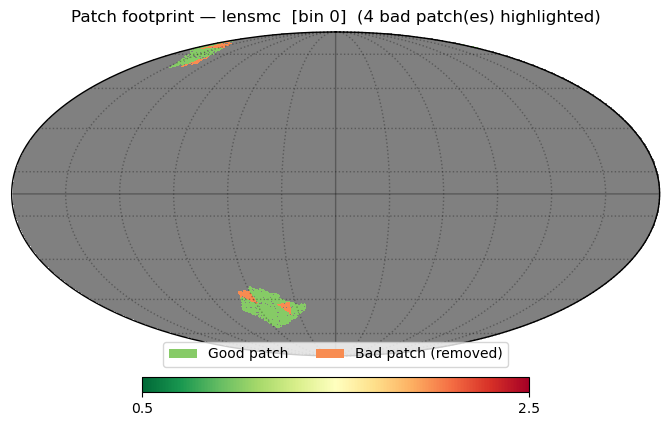

In [44]:
# Footprint map highlighting removed patches for each method/bin
for method in methods:
    for ibin in bins:
        bad_patches = set(np.where(all_chi2_bb_patch[method][ibin] / nlbins > 3)[0] + 1)

        # Build a labelled map: 0=outside, 1=good patch, 2=bad patch
        vis_map = np.full(hp.nside2npix(nside), hp.UNSEEN)
        for label in range(1, n_patches + 1):
            pix = jkmap == label
            vis_map[pix] = 2 if label in bad_patches else 1

        fig = plt.figure(figsize=(10, 5))
        hp.mollview(
            vis_map,
            fig=fig.number,
            title=f"Patch footprint — {method}  [bin {ibin}]  "
                  f"({len(bad_patches)} bad patch(es) highlighted)",
            cmap="RdYlGn_r",
            min=0.5, max=2.5,
            notext=True,
            hold=True,
        )
        hp.graticule(dpar=20, dmer=30, alpha=0.3)

        # Custom legend patches
        from matplotlib.patches import Patch
        legend_els = [
            Patch(facecolor=plt.cm.RdYlGn_r(0.25), label="Good patch"),
            Patch(facecolor=plt.cm.RdYlGn_r(0.75), label="Bad patch (removed)"),
        ]
        fig.get_axes()[0].legend(
            handles=legend_els, loc="lower center",
            bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=10,
        )
        plt.tight_layout()
        plt.show()


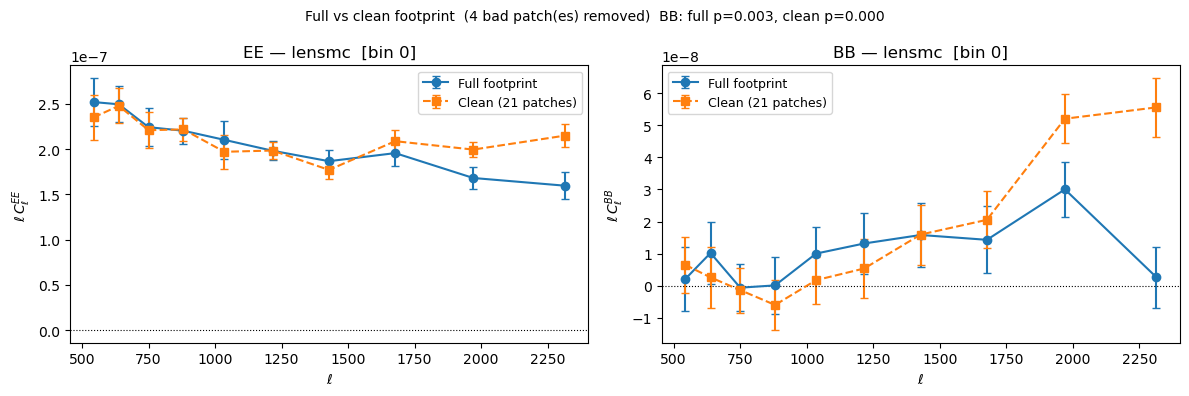

In [45]:
# Compare full-footprint EE and BB before and after removing bad patches,
# with jackknife error bars on both components.
for method in methods:
    for ibin in bins:
        bad_patches  = set(np.where(all_chi2_bb_patch[method][ibin] / nlbins > 3)[0] + 1)
        good_patches = [p for p in range(1, n_patches + 1) if p not in bad_patches]
        ell          = all_cl_full[method][ibin].ell

        full  = all_jk_chi2_bb[method][ibin]["full"]
        clean = all_jk_chi2_bb[method][ibin]["clean"]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for ax, (comp, cl_key, cov_key_str, label_comp) in zip(axes, [
            ("EE", "cl_ee", "cov_ee", "EE"),
            ("BB", "cl_bb", "cov_bb", "BB"),
        ]):
            cl_f   = full[cl_key]
            err_f  = np.sqrt(np.diag(full[cov_key_str]))
            ax.errorbar(ell, ell * cl_f, yerr=ell * err_f,
                        fmt="o-", color="C0", capsize=3, label="Full footprint")

            cl_c  = clean[cl_key]
            cov_c = clean[cov_key_str]
            if cl_c is not None and cov_c is not None:
                err_c = np.sqrt(np.diag(cov_c))
                ax.errorbar(ell, ell * cl_c, yerr=ell * err_c,
                            fmt="s--", color="C1", capsize=3,
                            label=f"Clean ({len(good_patches)} patches)")

            ax.axhline(0, color="k", lw=0.8, ls=":")
            ax.set_xlabel(r"$\ell$")
            ax.set_ylabel(rf"$\ell\,C_\ell^{{{label_comp}}}$")
            ax.set_title(f"{label_comp} — {method}  [bin {ibin}]")
            ax.legend(fontsize=9)

        fig.suptitle(
            f"Full vs clean footprint  ({len(bad_patches)} bad patch(es) removed)  "
            f"BB: full p={full['pval']:.3f}, clean p={clean['pval']:.3f}",
            fontsize=10,
        )
        plt.tight_layout()
        plt.show()
